In [1]:
!pip install earthpy gdal --quiet
!pip install segmentation-models-pytorch --quiet

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.4/1.4 MB 17.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 22.2/22.2 MB 84.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 154.8/154.8 kB 4.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 363.4/363.4 MB 4.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 664.8/664.8 MB 2.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 211.5/211.5 MB 7.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 56.3/56.3 MB 29.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 127.9/127.9 MB 8.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 207.5/207.5 MB 7.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 21.1/21.1 MB 48.6 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
pylibcugraph-cu12 24.12.0 requi

In [2]:
from osgeo import gdal, gdal_array
import os
import numpy as np
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt
from tqdm import tqdm
import random
import seaborn as sns
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
from skimage import io
import joblib
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader, random_split
import torchvision.transforms as transforms
import torch.optim as optim
from torch.cuda.amp import autocast, GradScaler
from torch import amp
import segmentation_models_pytorch as smp
from tensorflow.keras.preprocessing.image import ImageDataGenerator
import math
from PIL import Image

mask_path="/kaggle/input/cloud-masking-dataset/content/train/masks"
data_path ="/kaggle/input/cloud-masking-dataset/content/train/data"



2025-04-17 18:43:40.463500: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:477] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1744915420.745748      19 cuda_dnn.cc:8310] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1744915420.830162      19 cuda_blas.cc:1418] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered


In [3]:
def display_image(file_name,data_only):
    file_path=os.path.join(data_path, file_name)
    img_ds= gdal.Open(file_path, gdal.GA_ReadOnly)
    num_bands=img_ds.RasterCount
    if( not data_only):
        fig, axs = plt.subplots(1, 5, figsize=(10, 5))
    else:
        fig, axs = plt.subplots(1, 4, figsize=(10, 5))
    
    for i in range(1,num_bands+1):
      band = img_ds.GetRasterBand(i)
      img = band.ReadAsArray()
      axs[i-1].imshow(img, cmap='gray')
      axs[i-1].set_title('Original Image')
    if(not data_only):
        file_path=os.path.join(mask_path, file_name)
        img_ds= gdal.Open(file_path, gdal.GA_ReadOnly)
        num_bands=img_ds.RasterCount
        band = img_ds.GetRasterBand(1)
        img = band.ReadAsArray()
        axs[4].imshow(img, cmap='gray', vmin=0, vmax=1)        
        axs[4].set_title('Mask')
    plt.show()

***Display Random Images***

In [4]:

data= os.listdir(data_path)
# random_indices = np.random.permutation(len(data))[:10]
# for i in random_indices:
#     file_name=train_data[i]
#     display_image(file_name,False)

***Show Counts***

885it [00:07, 114.60it/s]

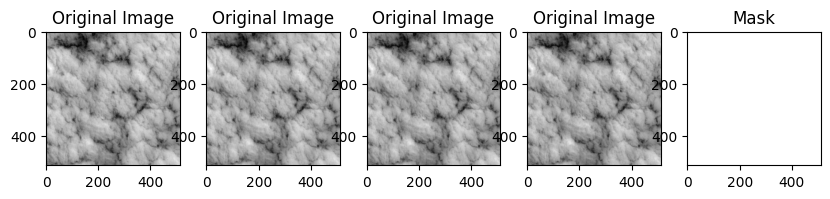

1637it [00:15, 110.20it/s]

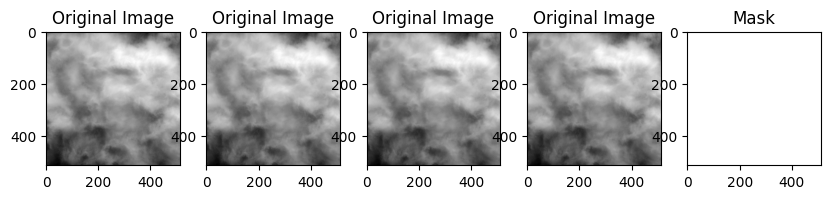

2410it [00:22, 105.33it/s]

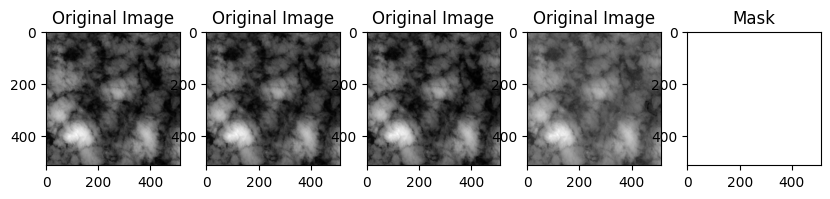

3060it [00:29, 111.49it/s]

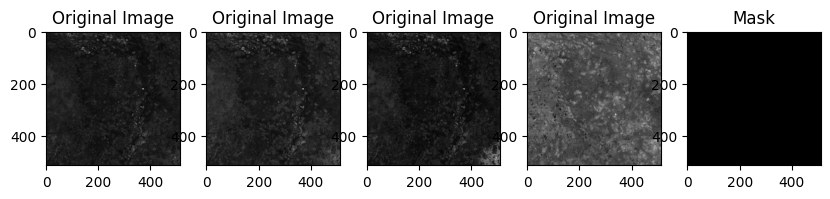

3160it [00:31, 84.78it/s]

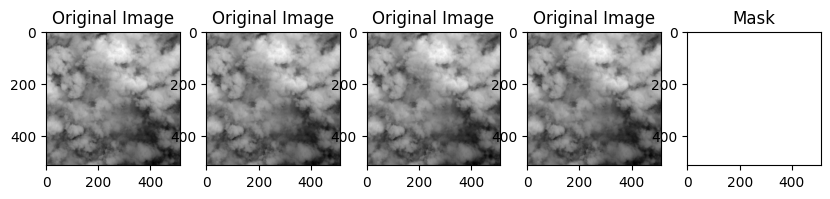

3869it [00:38, 105.11it/s]

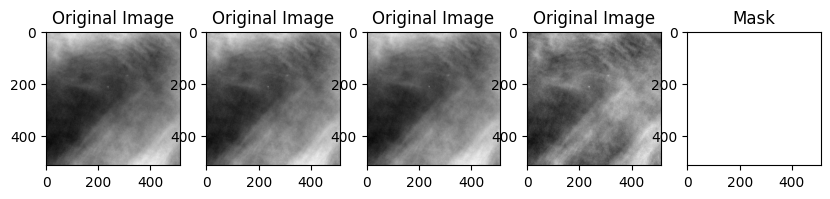

4639it [00:45, 102.43it/s]

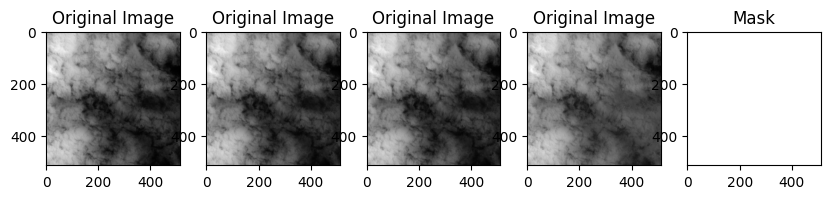

5446it [00:53, 108.66it/s]

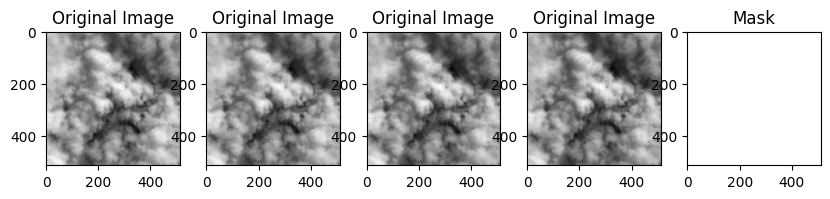

5955it [00:59, 109.88it/s]

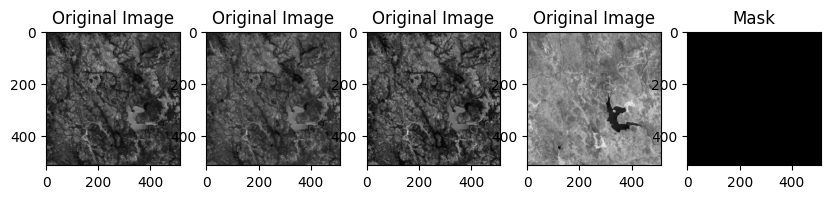

6167it [01:01, 107.27it/s]

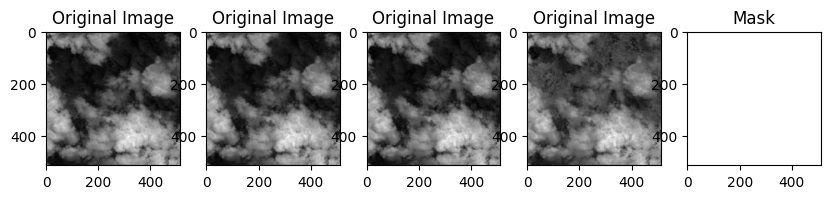

6932it [01:09, 107.32it/s]

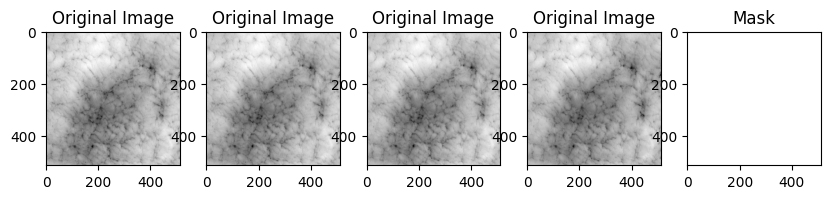

7753it [01:17, 105.44it/s]

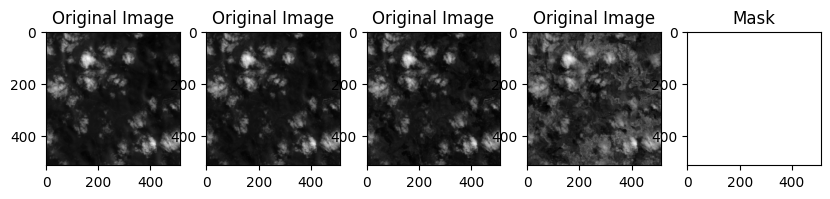

8630it [01:26, 109.82it/s]

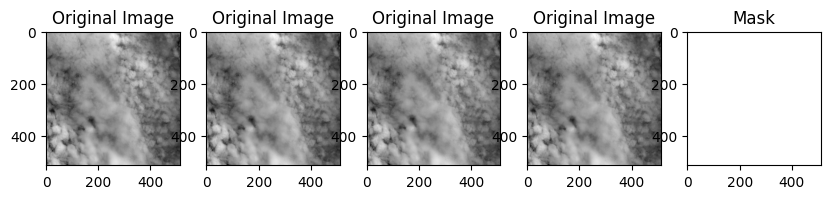

9008it [01:30, 105.80it/s]

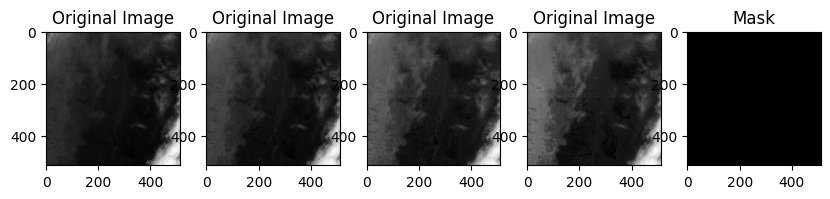

9447it [01:35, 101.57it/s]

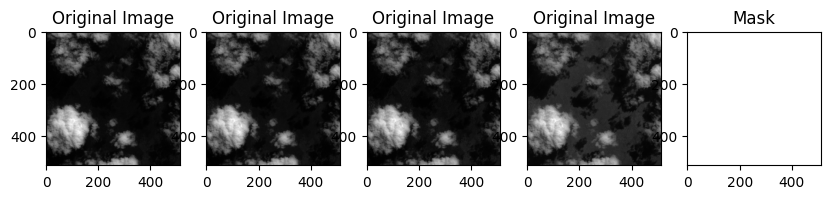

10164it [01:43, 97.67it/s] 

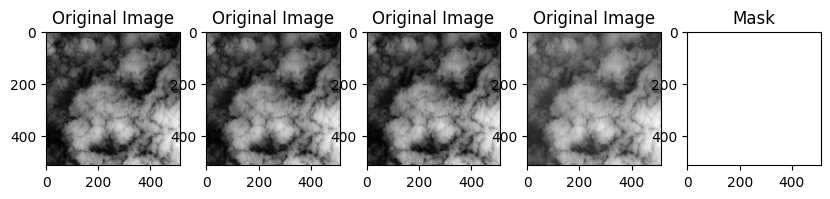

10573it [01:47, 98.30it/s] 


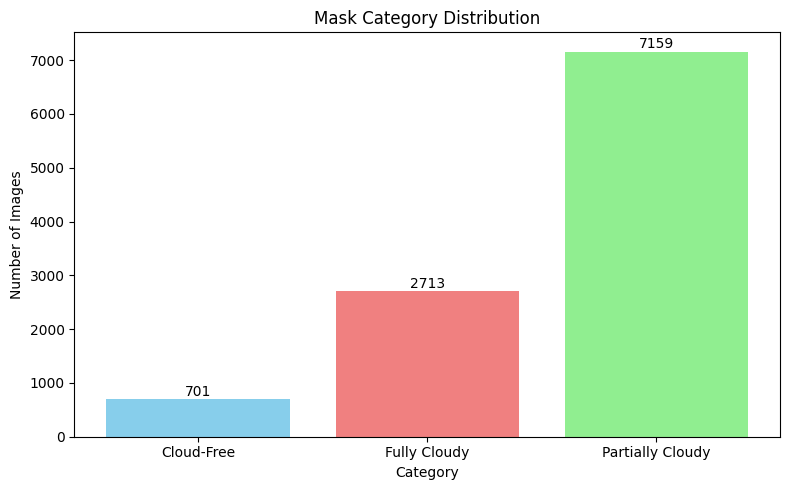

In [5]:
fully_cloud=0
partially_cloud=0
cloud_free=0
partially_cloud_data=[]
fully_cloud_data=[]
cloud_free_data=[]
for i,file_name in tqdm(enumerate(data)):
    file_path=os.path.join(mask_path, file_name)
    img_ds= gdal.Open(file_path, gdal.GA_ReadOnly)
    band = img_ds.GetRasterBand(1)
    img = band.ReadAsArray()
    if (np.all(img == 0)):
        cloud_free+=1
        cloud_free_data.append(file_name)
        if(cloud_free%200==0):
            display_image(file_name,False)
    elif (np.all(img == 1)):
        fully_cloud+=1
        fully_cloud_data.append(file_name)
        if(fully_cloud%200==0):
             display_image(file_name,False)
    else:
        partially_cloud+=1
        partially_cloud_data.append(file_name)
# 📊 Plotting
labels = ['Cloud-Free', 'Fully Cloudy', 'Partially Cloudy']
counts = [cloud_free, fully_cloud, partially_cloud]
plt.figure(figsize=(8, 5))
bars = plt.bar(labels, counts, color=['skyblue', 'lightcoral', 'lightgreen'])
plt.title('Mask Category Distribution')
plt.ylabel('Number of Images')
plt.xlabel('Category')
for bar in bars:
    yval = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2.0, yval + 5, int(yval), ha='center', va='bottom')
plt.tight_layout()
plt.show()


In [6]:
print("length of all data =",len(data))
print("length of partially_cloud_data (new data for training) =",len(partially_cloud_data))
print("length of cloud_free_data =",len(cloud_free_data))
print("length of fully_cloud_data =",len(fully_cloud_data))

data= np.array(partially_cloud_data)



length of all data = 10573
length of partially_cloud_data (new data for training) = 7159
length of cloud_free_data = 701
length of fully_cloud_data = 2713


In [7]:
def apply_pca(file_name,is_file_name):
    # === Select and Load a New Image ===
    if(is_file_name):
        new_image_path = os.path.join(data_path, file_name)  # pick one test image
    else:
        new_image_path=file_name
        
    img_ds = gdal.Open(new_image_path, gdal.GA_ReadOnly)
    
    # === Read Band 3 and 4 ===
    band3 = img_ds.GetRasterBand(3).ReadAsArray()
    band4 = img_ds.GetRasterBand(4).ReadAsArray()
    
    # === Stack and Reshape ===
    img_array = np.stack([band3, band4], axis=-1)  # shape: (H, W, 2)
    h, w, _ = img_array.shape
    reshaped = img_array.reshape(-1, 2)
    
    # === Transform with Scaler and PCA ===
    scaled = scaler.transform(reshaped)
    pca_output = pca.transform(scaled)
    
    # === Select First Principal Component and Reshape to Image ===
    pc1 = pca_output[:, 0].reshape(h, w)

    # plt.figure(figsize=(10, 6))
    # plt.imshow(pc1, cmap='gray')
    # plt.colorbar()
    # plt.title('First Principal Component of New Image')
    # plt.axis('off')
    # plt.show()

    return pc1



In [8]:
pca = joblib.load('/kaggle/input/pca/other/default/1/pca_model.joblib')
scaler = joblib.load('/kaggle/input/pca/other/default/1/scaler_model.joblib')

data_gen_args = dict(
    rotation_range=30,
    width_shift_range=0.1,
    height_shift_range=0.1,
    zoom_range=0.2,
    horizontal_flip=True,
    vertical_flip=True,
    fill_mode='nearest'
)

# Same seed ensures same transform on image and mask
image_datagen = ImageDataGenerator(**data_gen_args)
mask_datagen  = ImageDataGenerator(**data_gen_args)



# Create directories to save augmented data
os.makedirs("images", exist_ok=True)
os.makedirs("masks", exist_ok=True)

new_data=data
if isinstance(new_data, np.ndarray):
    new_data = new_data.tolist()


img_count = 0

for img in tqdm(data,desc="reading data and augmenting ..."):
    img_pca=apply_pca(img,True)
    new_mask_path = os.path.join(mask_path, file_name)  # pick one test image
    mask_data = gdal.Open(new_mask_path, gdal.GA_ReadOnly)
    mask = mask_data.GetRasterBand(1).ReadAsArray()
    # Save image
    img_pca_pil = Image.fromarray(img_pca.astype(np.uint8))
    img_pca_pil.save(f"images/{img}")
    # Save the corresponding mask
    mask_pil = Image.fromarray(mask.astype(np.uint8))
    mask_pil.save(f"masks/{img}")
    # Reshape the image for the generator
    img_pca = np.expand_dims(img_pca, axis=-1)  # Shape (512, 512, 1) for a single channel image
    mask = np.expand_dims(mask, axis=-1)  # Same for mask if it's grayscale

    seed = np.random.randint(0, 10000)  # You can adjust the range based on your needs
    # Create generators
    aug_images = image_datagen.flow(np.expand_dims(img_pca, axis=0), batch_size=1, seed=seed)  # Add batch dimension
    aug_masks = mask_datagen.flow(np.expand_dims(mask, axis=0), batch_size=1, seed=seed)

    # Get augmented data
    img_batch = next(aug_images)
    mask_batch = next(aug_masks)

    
    img_batch = img_batch.squeeze()  # Remove extra dimensions
    mask_batch = mask_batch.squeeze()  # Remove extra dimensions


    # Save the augmented image and mask
    img_pil = Image.fromarray(img_batch)
    mask_pil = Image.fromarray(mask_batch)

    # save the augmented data
    img_pil.save(f"images/aug_{img_count}.tif")
    mask_pil.save(f"masks/aug_{img_count}.tif")
    new_data.append(f"aug_{img_count}.tif")
    img_count += 1


    
new_data = np.array(new_data)
print("data len = ", new_data.shape)
# Save the array to a .npy file
np.save('new_data.npy', new_data)




# img = (img_batch[j] * 255).astype(np.uint8)  # Rescale if needed
# mask = (mask_batch[j] * 255).astype(np.uint8)

        


reading data and augmenting ...: 100%|██████████| 7159/7159 [09:38<00:00, 12.38it/s]

data len =  (14318,)


In [9]:
# train_data, val_test = train_test_split(data, test_size=0.2, random_state=42)
# val, test = train_test_split(val_test, test_size=0.5, random_state=42)

# print(" train data = ", train_data.shape)
# print(" validation data = ",val.shape)
# print(" test data = ",test.shape)

***Show Correlation Between Bands***

In [10]:
# subset = random.sample(train_data, k=1000)
# all_pixels = []
# for file_path in tqdm(subset):
#     file_path=os.path.join(data_path, file_path)
#     img_ds = gdal.Open(file_path, gdal.GA_ReadOnly)
#     width = img_ds.RasterXSize
#     height = img_ds.RasterYSize
#     num_bands = img_ds.RasterCount
#     img_array = np.zeros((height, width, num_bands), dtype=np.float32)
#     for i in range(num_bands):
#         band = img_ds.GetRasterBand(i + 1)
#         img_array[:, :, i] = band.ReadAsArray()
#     reshaped = img_array.reshape(-1, 4)
#     all_pixels.append(reshaped)

# combined = np.vstack(all_pixels)  # Shape: (total_pixels, 4)
# corr = np.corrcoef(combined.T)
# sns.heatmap(corr, annot=True, cmap='coolwarm', xticklabels=['B1', 'B2', 'B3', 'B4'], yticklabels=['B1', 'B2', 'B3', 'B4'])
# plt.title("Global Band Correlation Across 1000 Images")
# plt.show()



***Apply PCA On Bands 3&4***

In [11]:
# subset = random.sample(train_data, k=1000)
# images = []
# for fname in subset:
#     img_path = os.path.join(data_path, fname)
#     img_ds = gdal.Open(img_path, gdal.GA_ReadOnly)
#     for i in [3,4]:
#         band = img_ds.GetRasterBand(i)
#         img_array[:, :, i-3] = band.ReadAsArray()
#     reshaped = img_array.reshape(-1, 2)
#     images.append(reshaped)


# X = np.vstack(images)  # Shape: (total_pixels, 2)

# # Scale the data to have zero mean and unit variance along each feature axis
# scaler = StandardScaler()
# X_scaled = scaler.fit_transform(X)

# # Perform PCA with 3 components
# pca = PCA()
# pca.fit(X_scaled)
# output = pca.transform(X_scaled)

# # Scree plot of the eigen value ratios
# explained_variance_ratio = pca.explained_variance_ratio_
# plt.figure()
# plt.plot(explained_variance_ratio, marker='o', linestyle='--')
# plt.xlabel('Principal Component')
# plt.ylabel('Explained Variance Ratio')
# plt.title('Explained Variance Ratio of Principal Components')
# plt.show()

# # Plot the 3D graph of the PCA (scatter plot of first 3 principal components)
# pc1 = output[:, 0]




# Save the fitted PCA model
# joblib.dump(pca, 'pca_model.joblib')
# joblib.dump(scaler, 'scaler_model.joblib')


# === Load Saved Models ===


In [12]:


# class CloudMaskDataset(Dataset):
#     def __init__(self,image_files):
#         self.image_paths = [os.path.join(data_path, fname) for fname in image_files]
#         self.mask_paths = [os.path.join(mask_path, fname) for fname in image_files]

#     def __len__(self):
#         return len(self.image_paths)

#     def __getitem__(self, idx):
#         # read img
#         img_data= gdal.Open(self.data_paths[idx], gdal.GA_ReadOnly)
#         img_band = img_data.GetRasterBand(1)
#         img = img_band.ReadAsArray()
#         # read mask
#         mask_data= gdal.Open(self.mask_paths[idx], gdal.GA_ReadOnly)
#         band = mask_data.GetRasterBand(1)
#         mask = band.ReadAsArray()
        

#         # # Normalize to [0, 1]
#         img = (img.astype(np.float32)-img.min()) / (img.max()-img.min())

#         # Expand channel dimension: [H, W] → [1, H, W]
#         img = np.expand_dims(img, axis=0)
#         mask = np.expand_dims(mask, axis=0)

#         return torch.from_numpy(img), torch.from_numpy(mask)


In [13]:


# class DoubleConv(nn.Module):
#     """(conv => BN => ReLU) * 2"""
#     def __init__(self, in_channels, out_channels):
#         super(DoubleConv, self).__init__()
#         self.conv = nn.Sequential(
#             nn.Conv2d(in_channels, out_channels, 3, padding=1),
#             nn.BatchNorm2d(out_channels),
#             nn.ReLU(inplace=True),

#             nn.Conv2d(out_channels, out_channels, 3, padding=1),
#             nn.BatchNorm2d(out_channels),
#             nn.ReLU(inplace=True),
#         )

#     def forward(self, x):
#         return self.conv(x)


# class UNet(nn.Module):
#     def __init__(self, in_channels=1, out_channels=1):
#         super(UNet, self).__init__()

#         self.down1 = DoubleConv(in_channels, 64)
#         self.pool1 = nn.MaxPool2d(2)

#         self.down2 = DoubleConv(64, 128)
#         self.pool2 = nn.MaxPool2d(2)

#         self.down3 = DoubleConv(128, 256)
#         self.pool3 = nn.MaxPool2d(2)

#         self.down4 = DoubleConv(256, 512)
#         self.pool4 = nn.MaxPool2d(2)

#         self.bottleneck = DoubleConv(512, 1024)

#         self.up4 = nn.ConvTranspose2d(1024, 512, 2, stride=2)
#         self.conv4 = DoubleConv(1024, 512)

#         self.up3 = nn.ConvTranspose2d(512, 256, 2, stride=2)
#         self.conv3 = DoubleConv(512, 256)

#         self.up2 = nn.ConvTranspose2d(256, 128, 2, stride=2)
#         self.conv2 = DoubleConv(256, 128)

#         self.up1 = nn.ConvTranspose2d(128, 64, 2, stride=2)
#         self.conv1 = DoubleConv(128, 64)

#         self.final_conv = nn.Conv2d(64, out_channels, kernel_size=1)

#     def forward(self, x):
#         # Encoder
#         d1 = self.down1(x)
#         p1 = self.pool1(d1)

#         d2 = self.down2(p1)
#         p2 = self.pool2(d2)

#         d3 = self.down3(p2)
#         p3 = self.pool3(d3)

#         d4 = self.down4(p3)
#         p4 = self.pool4(d4)

#         # Bottleneck
#         bn = self.bottleneck(p4)

#         # Decoder
#         up4 = self.up4(bn)
#         cat4 = torch.cat([up4, d4], dim=1)
#         d4 = self.conv4(cat4)

#         up3 = self.up3(d4)
#         cat3 = torch.cat([up3, d3], dim=1)
#         d3 = self.conv3(cat3)

#         up2 = self.up2(d3)
#         cat2 = torch.cat([up2, d2], dim=1)
#         d2 = self.conv2(cat2)

#         up1 = self.up1(d2)
#         cat1 = torch.cat([up1, d1], dim=1)
#         d1 = self.conv1(cat1)

#         out = self.final_conv(d1)
#         return torch.sigmoid(out)  # For binary mask output




In [14]:
# def train(model, loader, optimizer, criterion):
#     model.train()
#     epoch_loss = 0
#     for imgs, masks in tqdm(loader,desc="training loop"):
#         torch.cuda.empty_cache()
#         imgs = imgs.to(torch.float32).to(device)
#         masks = masks.to(torch.float32).to(device)
#         scaler = GradScaler()
#         with autocast():
#             outputs = model(imgs)
#             loss = criterion(outputs, masks)

#         optimizer.zero_grad()
#         loss.backward()
#         optimizer.step()

#         epoch_loss += loss.item()
#     return epoch_loss / len(loader)

In [15]:
# def dice_coefficient(preds, targets, smooth=1e-6):
#     preds = torch.sigmoid(preds)  # Convert logits to probabilities
#     preds = (preds > 0.5).float()  # Threshold to binary mask

#     intersection = (preds * targets).sum(dim=(1, 2, 3))
#     union = preds.sum(dim=(1, 2, 3)) + targets.sum(dim=(1, 2, 3))

#     dice = (2. * intersection + smooth) / (union + smooth)
#     return dice.mean()


In [16]:
# def evaluate(model, loader, criterion):
#     model.eval()
#     epoch_loss = 0
#     epoch_dice = 0
#     with torch.no_grad():
#         for imgs, masks in tqdm(loader,desc="testing loop"):
#             torch.cuda.empty_cache()
#             imgs = imgs.to(torch.float32).to(device)
#             masks = masks.to(torch.float32).to(device)
#             scaler = GradScaler()
#             with autocast():
#                 outputs = model(imgs)
#                 loss = criterion(outputs, masks)
            
#             dice = dice_coefficient(outputs, masks)
#             epoch_loss += loss.item()
#             epoch_dice += dice.item()

#     avg_loss = epoch_loss / len(loader)
#     avg_dice = epoch_dice / len(loader)
#     return avg_loss, avg_dice


In [17]:
# print(train_data[:10])

In [18]:


# # Create dataset and dataloader for train_data
# train_dataset = CloudMaskDataset(train_data)
# train_loader = DataLoader(train_dataset, batch_size=16, shuffle=True,num_workers=4)

# # Create dataset and dataloader for validation
# val_dataset = CloudMaskDataset(val)
# val_loader = DataLoader(val_dataset, batch_size=16, shuffle=True,num_workers=4)

# # Create dataset and dataloader tset
# test_dataset = CloudMaskDataset(test)
# test_loader = DataLoader(test_dataset, batch_size=16, shuffle=True,num_workers=4)




In [19]:

# # Check GPU
# device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
# print(f"Using device: {device}")

# # Initialize model and move to device
# model = UNet(in_channels=1, out_channels=1)
# model = torch.nn.DataParallel(model)
# model = model.to(device)

# # Define loss and optimizer
# # criterion = nn.BCEWithLogitsLoss()  # For binary segmentation
# criterion =smp.losses.DiceLoss(mode='binary')
# optimizer = optim.Adam(model.parameters(), lr=0.001)


In [20]:
# epochs=20
# for epoch in range(epochs+1):
#     # print(torch.cuda.memory_summary())
#     train_loss = train(model, train_loader, optimizer, criterion)
#     val_loss, val_dice = evaluate(model, val_loader, criterion)
#     print(f"Epoch {epoch+1}/{epochs}, Train Loss: {train_loss:.4f}, Val Loss: {val_loss:.4f}, Val Dice: {val_dice:.4f}")


In [21]:
# torch.save(model, 'unet_model.pth')

# test_loss, test_dice = evaluate(model, test_loader, criterion)
# print(f" test Loss: {test_loss:.4f}, test Dice: {test_dice:.4f}")